# Importar paquetes

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carga de datos

In [2]:
df = pd.read_csv('./data/titanic_clean.csv')

# Analisis

In [3]:
df.sample(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
42,0,3,male,28.0,0,0,7.8958,C
96,0,1,male,71.0,0,0,34.6542,C
883,0,2,male,28.0,0,0,10.5000,S
567,0,3,female,29.0,0,4,21.0750,S


In [4]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

# Cuenta de sobrevivientes

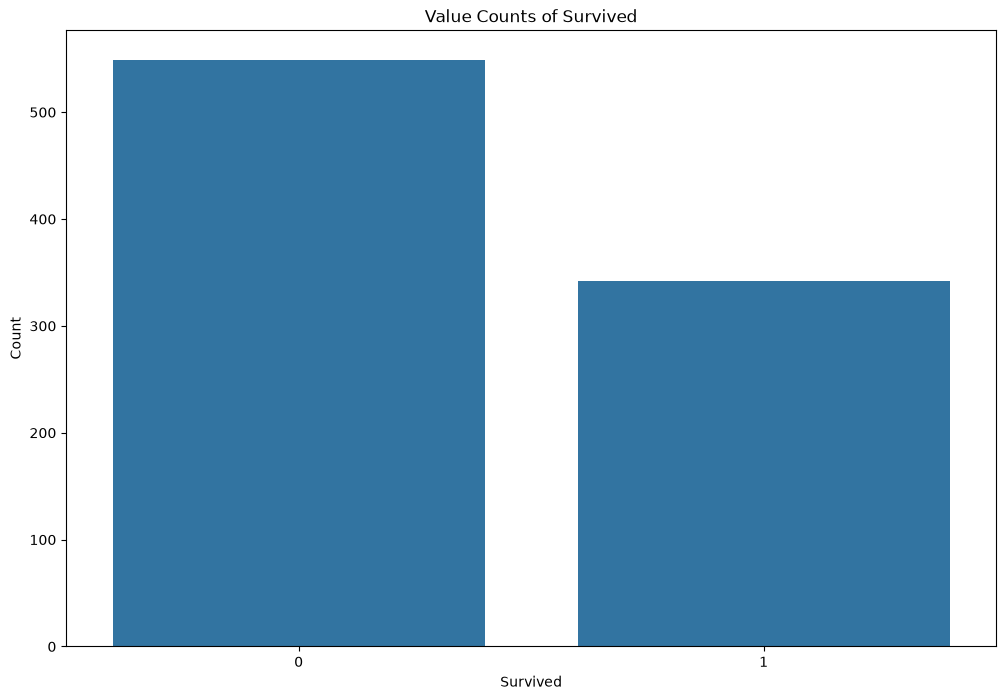

In [5]:
plt.figure(figsize=(12, 8))

sns.barplot(x = df['Survived'].value_counts().index, y = df['Survived'].value_counts())
plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

# Supervivencia por clase en el Titanic

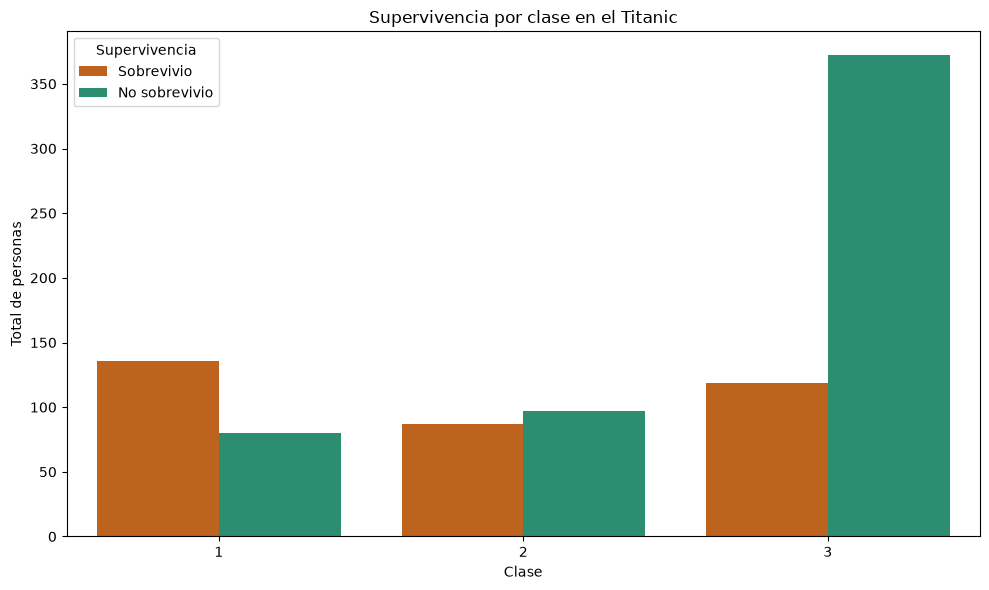

In [6]:
survival_by_class = df.copy()
survival_by_class['Supervivencia'] = survival_by_class['Survived'].map({0: 'No sobrevivio', 1: 'Sobrevivio'})

plt.figure(figsize=(10, 6))
sns.countplot(
    data=survival_by_class,
    x='Pclass',
    hue='Supervivencia',
    order=[1, 2, 3],
    palette=['#d95f02', '#1b9e77']
)

plt.title('Supervivencia por clase en el Titanic')
plt.xlabel('Clase')
plt.ylabel('Total de personas')
plt.legend(title='Supervivencia')
plt.tight_layout()
plt.show()

# Supervivencia por sexo en el titanic

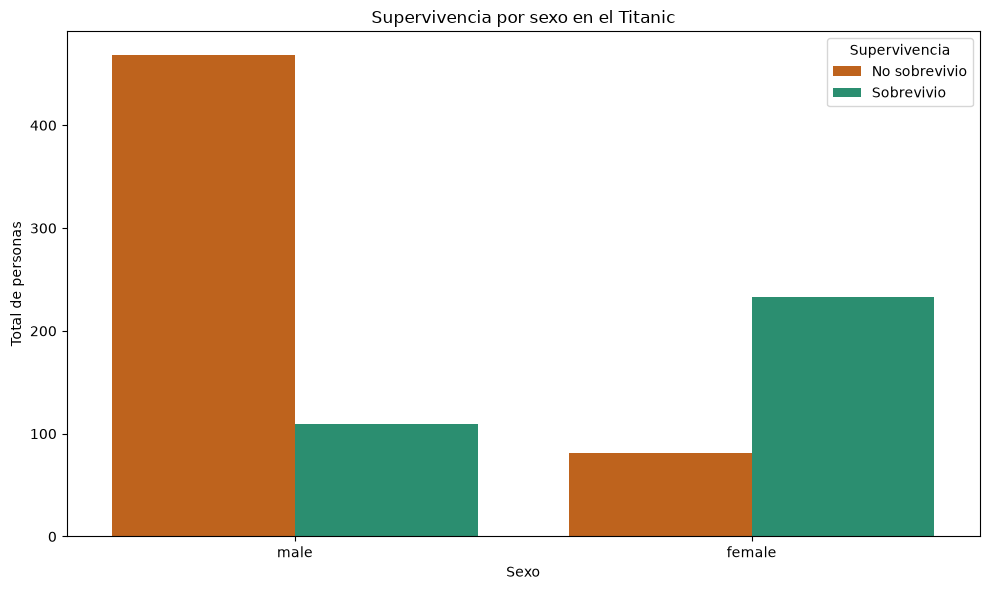

In [8]:
survival_by_sex = df.copy()
survival_by_sex['Supervivencia'] = survival_by_sex['Survived'].map({0: 'No sobrevivio', 1: 'Sobrevivio'})

plt.figure(figsize=(10, 6))
sns.countplot(
    data=survival_by_sex,
    x='Sex',
    hue='Supervivencia',
    palette=['#d95f02', '#1b9e77']
)

plt.title('Supervivencia por sexo en el Titanic')
plt.xlabel('Sexo')
plt.ylabel('Total de personas')
plt.legend(title='Supervivencia')
plt.tight_layout()
plt.show()

# Supervivencia por puerto de embarque

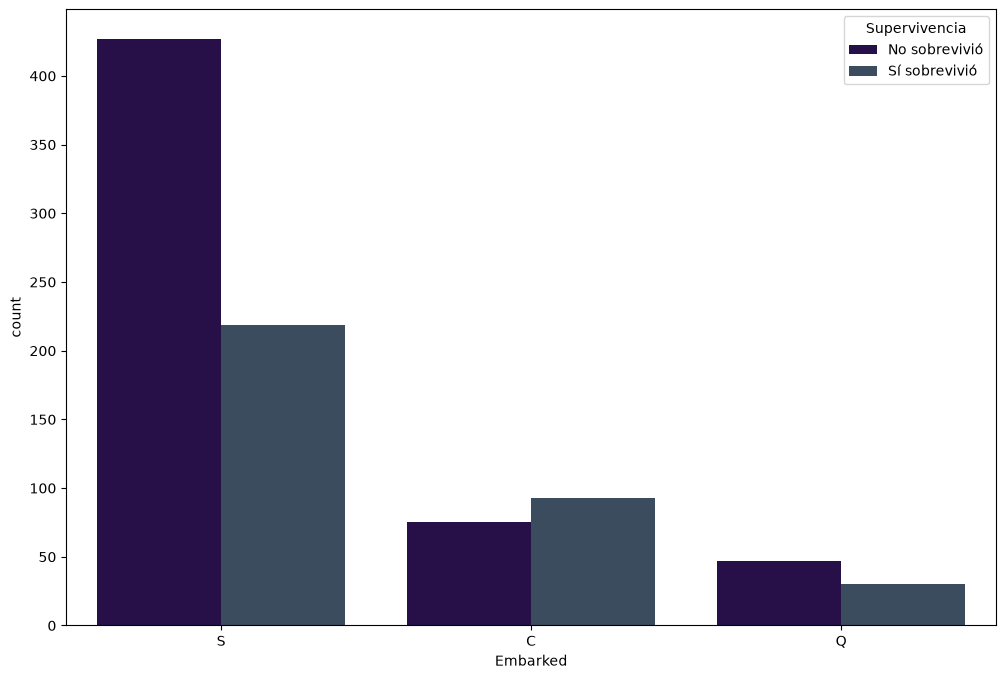

In [9]:
plt.figure(figsize = (12, 8))

# colores para cada una de las clases
color = ['#240750', '#344C64']

sns.countplot(df, x = 'Embarked', hue = 'Survived', palette=color) 
plt.legend(title = 'Supervivencia', labels = ['No sobrevivió', 'Sí sobrevivió'])
plt.show()

# Distribucion de edades

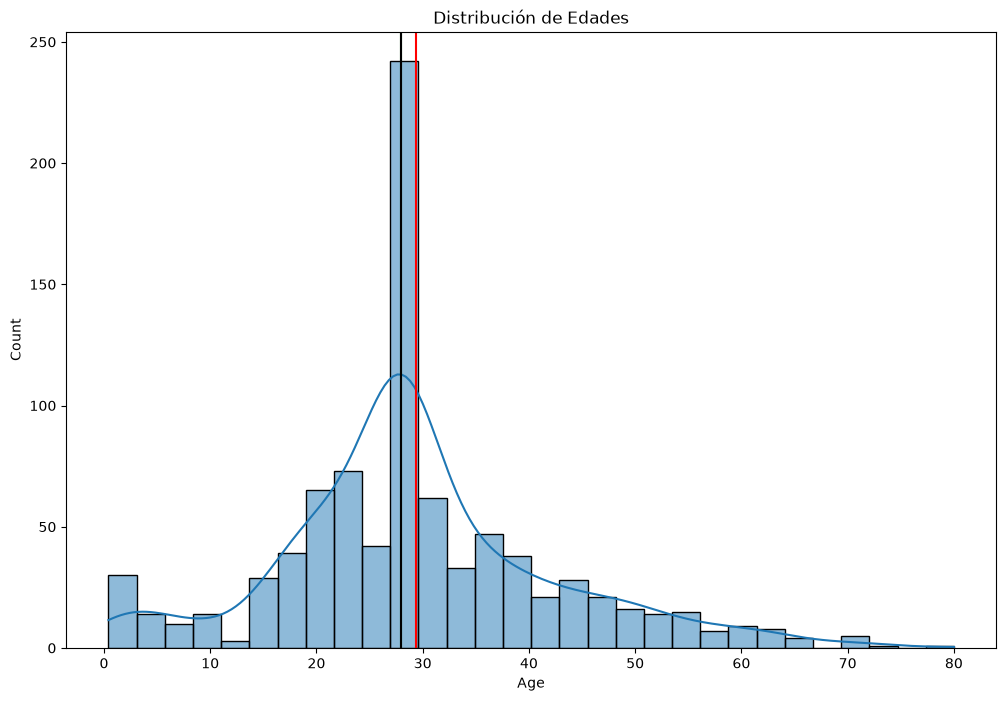

Media: 29.36158249158249
Mediana: 28.0
Moda: 28.0


In [10]:
plt.figure(figsize = (12, 8))

sns.histplot(df, x = 'Age', kde = True)
plt.title('Distribución de Edades')
plt.axvline(df['Age'].mean(), color = 'red')
plt.axvline(df['Age'].median(), color = 'green')
plt.axvline(df['Age'].mode()[0], color = 'black')
plt.show()

# Print the results
print(f"Media: {df['Age'].mean()}")
print(f"Mediana: {df['Age'].median()}")
print(f"Moda: {df['Age'].mode()[0]}")

# Matriz de correlacion

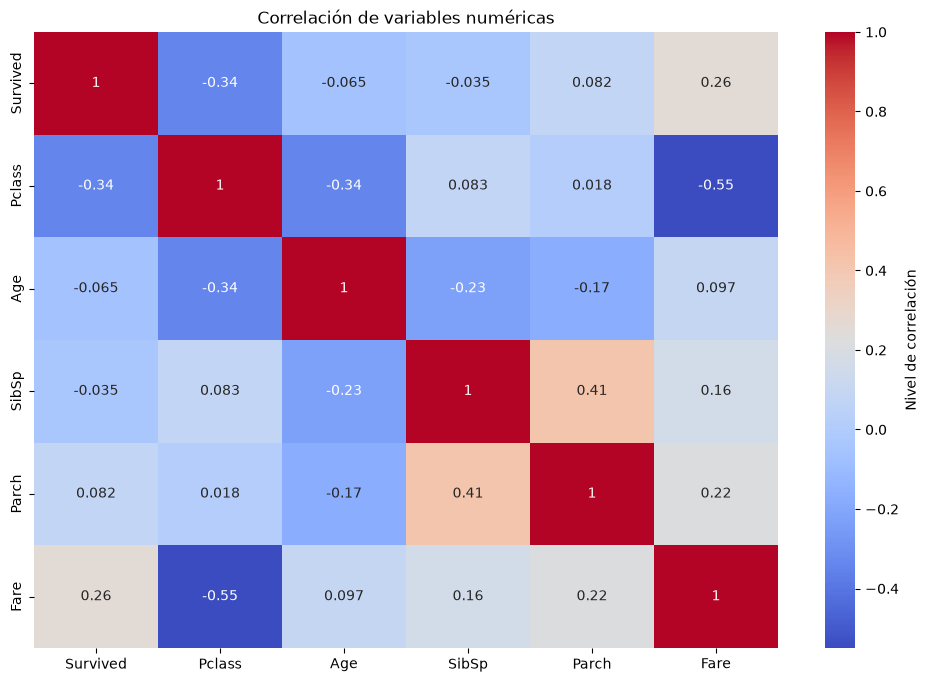

In [11]:
plt.figure(figsize = (12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, 
            cbar=True,  # Activar la barra de colores
            cmap='coolwarm',  # Cambiar la paleta de colores
            cbar_kws={'label': 'Nivel de correlación'})  # Etiqueta para la barra de colores
plt.title('Correlación de variables numéricas')
plt.show()